In [ ]:
from google.colab import files
uploaded = files.upload()

Saving dbscan.csv to dbscan.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

In [ ]:
df = pd.read_csv("dbscan.csv")

In [ ]:
df.head()

,X,Y
0,1.0,1.1
1,1.2,0.9
2,0.9,1.0
3,1.1,1.2
4,1.3,1.1


In [ ]:
df.shape

(40, 2)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       40 non-null     float64
 1   Y       40 non-null     float64
dtypes: float64(2)
memory usage: 772.0 bytes


In [ ]:
X = df[['X', 'Y']]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
dbscan = DBSCAN(
    eps=0.30,
    min_samples=3
)

labels = dbscan.fit_predict(X_scaled)

In [ ]:
df['Cluster'] = labels

In [ ]:
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print("\nNumber of Clusters:", n_clusters)


Number of Clusters: 4


In [ ]:
noise = list(labels).count(-1)
print("Noise Points:", noise)

Noise Points: 0


In [ ]:
mask = labels != -1

if len(set(labels[mask])) > 1:
    score = silhouette_score(X_scaled[mask], labels[mask])
    print("\nSilhouette Score:", round(score, 4))
else:
    print("Silhouette Score cannot be calculated.")


Silhouette Score: 0.9463


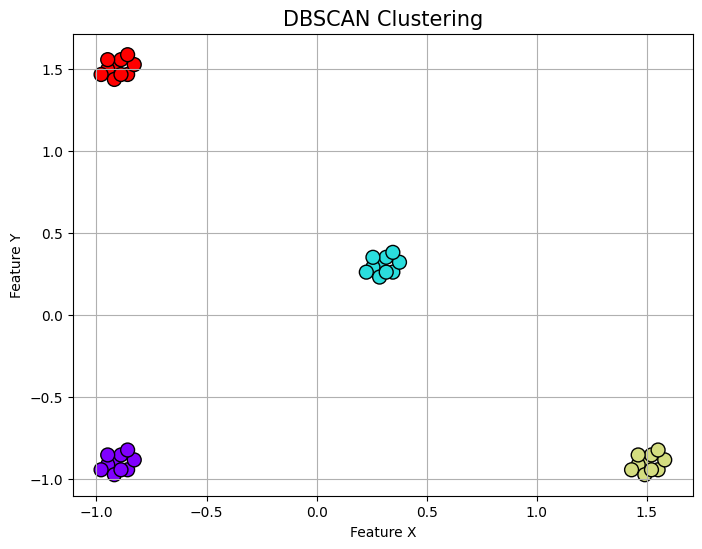

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_scaled[:,0],
    X_scaled[:,1],
    c=labels,
    cmap='rainbow',
    s=100,
    edgecolor='black'
)

plt.title("DBSCAN Clustering", fontsize=15)
plt.xlabel("Feature X")
plt.ylabel("Feature Y")
plt.grid(True)

plt.show()